<a href="https://colab.research.google.com/github/sadmansalvi/gdp_growth_forecaster/blob/main/Group%201%20Project%20Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 01: Importing necessary packages for ML

In [26]:
import warnings
warnings.filterwarnings('ignore')

!pip install -q wbdata scikit-learn seaborn scipy xgboost

import sys
import time
import numpy as np
import pandas as pd
import wbdata as wb
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

np.random.seed(42)

import importlib.metadata
from IPython.display import display

packages = [
    "wbdata", "scikit-learn", "xgboost", "pandas", "numpy", "matplotlib", "seaborn", "scipy"
]

print("\n" + "="*50)
print("CORE DEPENDENCY VERSIONS")
print("="*50)

for pkg in packages:
    try:
        version = importlib.metadata.version(pkg)
        print(f" {pkg.ljust(20)} : {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f" {pkg.ljust(20)} : NOT INSTALLED")



CORE DEPENDENCY VERSIONS
 wbdata               : 1.1.0
 scikit-learn         : 1.6.1
 xgboost              : 3.2.0
 pandas               : 2.2.2
 numpy                : 2.0.2
 matplotlib           : 3.10.0
 seaborn              : 0.13.2
 scipy                : 1.16.3


#Step 02: Importing Data

In [27]:
country_groups = {
    "G7": ["USA", "DEU", "JPN", "GBR", "FRA", "ITA", "CAN"],
    "BRICS": ["BRA", "RUS", "IND", "CHN", "ZAF"],
    "South Asia": ["BGD", "PAK", "LKA", "NPL"]
}

target_countries = [code for group in country_groups.values() for code in group]

indicators = {
    "NY.GDP.MKTP.CD": "GDP (in Billion US$)",

    "SE.XPD.TOTL.GD.ZS": "Education Expenditure",
    "SH.XPD.CHEX.GD.ZS": "Health Expenditure",
    "MS.MIL.XPND.GD.ZS": "Military Expenditure",
    "NE.GDI.FTOT.ZS": "Infrastructure Expenditure",
    "BX.KLT.DINV.WD.GD.ZS": "Foreign Direct Investment",
    "NE.TRD.GNFS.ZS": "Trade",

    "NY.GDP.MKTP.KD.ZG": "GDP Growth %"
}

print(f"Configuration set for {len(target_countries)} countries.")

Configuration set for 16 countries.


#Step 03: Data Preprocessing

Fetching data for 16 countries...
Data Shape: (528, 10)

Missing Values per Indicator:
country                         0
year                            0
GDP (in Billion US$)            0
Education Expenditure         177
Health Expenditure            139
Military Expenditure            0
Infrastructure Expenditure      5
Foreign Direct Investment       4
Trade                           5
GDP Growth %                    0
dtype: int64


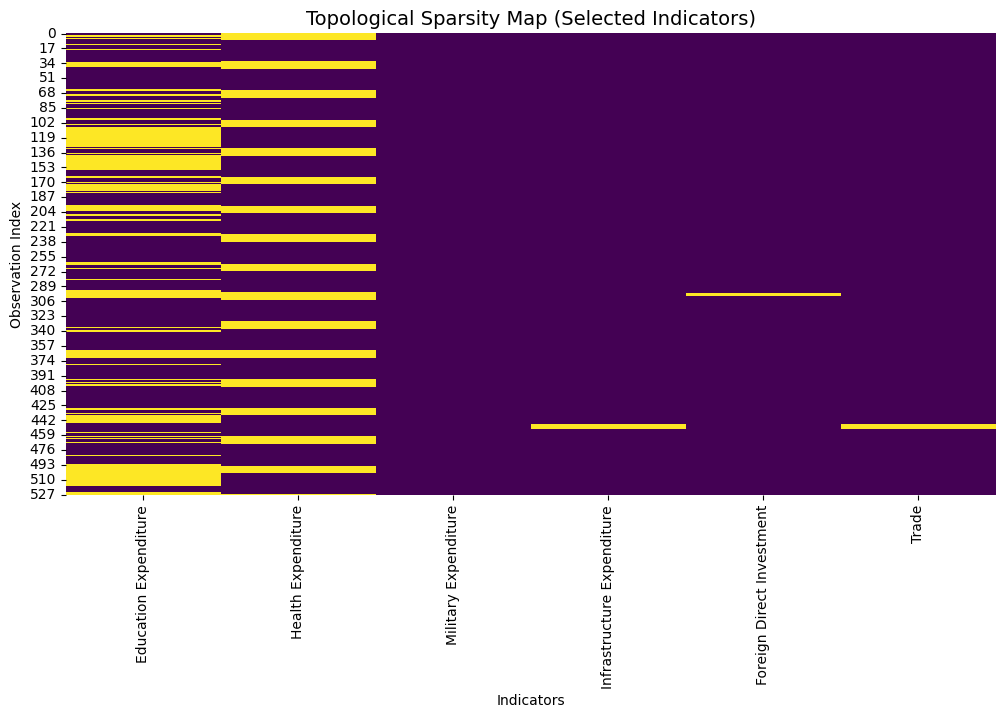

In [28]:
print(f"Fetching data for {len(target_countries)} countries...")

df = wb.get_dataframe(indicators, country=target_countries)

df.reset_index(inplace=True)

df['year'] = pd.to_datetime(df['date']).dt.year.astype(int)

df = df[(df['year'] >= 1992) & (df['year'] <= 2024)].copy()

if 'GDP (in Billion US$)' in df.columns:
    df['GDP (in Billion US$)'] = df['GDP (in Billion US$)'] / 1e9

cols = ['country', 'year'] + [c for c in df.columns if c not in ['country', 'year', 'date']]
df = df[cols].sort_values(by=['country', 'year']).reset_index(drop=True)

print("Data Shape:", df.shape)
print("\nMissing Values per Indicator:")
print(df.isnull().sum())

plt.figure(figsize=(12, 6))

columns_to_exclude = ['country', 'year', 'GDP Growth %', 'GDP (in Billion US$)']
data_to_plot = df.drop(columns=[col for col in columns_to_exclude if col in df.columns])

sns.heatmap(data_to_plot.isnull(), cbar=False, cmap='viridis')

plt.title('Topological Sparsity Map (Selected Indicators)', fontsize=14)
plt.xlabel('Indicators')
plt.ylabel('Observation Index')

plt.savefig('sparsity_map.png', bbox_inches='tight')

##Histogram

In [29]:
df

,country,year,GDP (in Billion US$),Education Expenditure,Health Expenditure,Military Expenditure,Infrastructure Expenditure,Foreign Direct Investment,Trade,GDP Growth %
0,Bangladesh,1992,31.708875,1.63177,NaN,1.360503,17.305029,0.011738,19.934006,5.442686
1,Bangladesh,1993,33.166519,1.69263,NaN,1.429391,17.946832,0.042362,23.121583,4.711562
2,Bangladesh,1994,33.768661,NaN,NaN,1.529024,18.402556,0.033012,22.865865,3.890126
3,Bangladesh,1995,37.939749,NaN,NaN,1.566693,19.119796,0.004998,28.209496,5.121278
4,Bangladesh,1996,46.438484,NaN,NaN,1.539074,20.729951,0.029135,26.076088,4.522919
...,...,...,...,...,...,...,...,...,...,...
523,United States,2020,21060.473613,5.39531,18.515974,3.645188,21.888724,0.650821,23.401563,-2.163029
524,United States,2021,23315.080560,5.42038,17.352077,3.404520,21.615954,2.049986,25.609558,6.055053
525,United States,2022,25604.848908,NaN,16.528751,3.309477,21.709978,1.628168,27.313940,2.512375
526,United States,2023,27292.170793,NaN,16.694149,3.304442,21.726498,1.326183,25.290330,2.887556


In [30]:
df.drop(columns=['year']).describe()

,GDP (in Billion US$),Education Expenditure,Health Expenditure,Military Expenditure,Infrastructure Expenditure,Foreign Direct Investment,Trade,GDP Growth %
count,528.000000,351.000000,389.000000,528.000000,523.000000,524.000000,523.000000,528.000000
mean,2654.596985,3.969788,7.452648,2.128447,22.611203,1.696504,45.951608,3.158067
std,4299.054190,1.296963,3.744542,1.160369,6.178657,1.718361,16.840001,3.536357
min,3.401212,1.130950,1.772019,0.700151,11.456532,-1.736810,15.635591,-14.531074
25%,288.702430,3.144640,4.037158,1.255771,18.662264,0.543134,31.334679,1.399207
50%,1411.200649,4.098658,7.859468,1.715192,21.342676,1.243158,45.994086,3.030709
75%,2723.095506,4.886895,10.106806,2.725272,25.046529,2.317661,57.827662,5.139155
max,28750.956131,7.678350,18.515974,7.052339,44.075543,12.608532,110.577065,14.299611


#Step 04:Identifying Features and Target


In [31]:
numerical_features = [
    'Education Expenditure',
    'Health Expenditure',
    'Military Expenditure',
    'Infrastructure Expenditure',
    'Foreign Direct Investment',
    'Trade'
]

categorical_features = ['country']

X = df[categorical_features+numerical_features]
y = df['GDP Growth %']


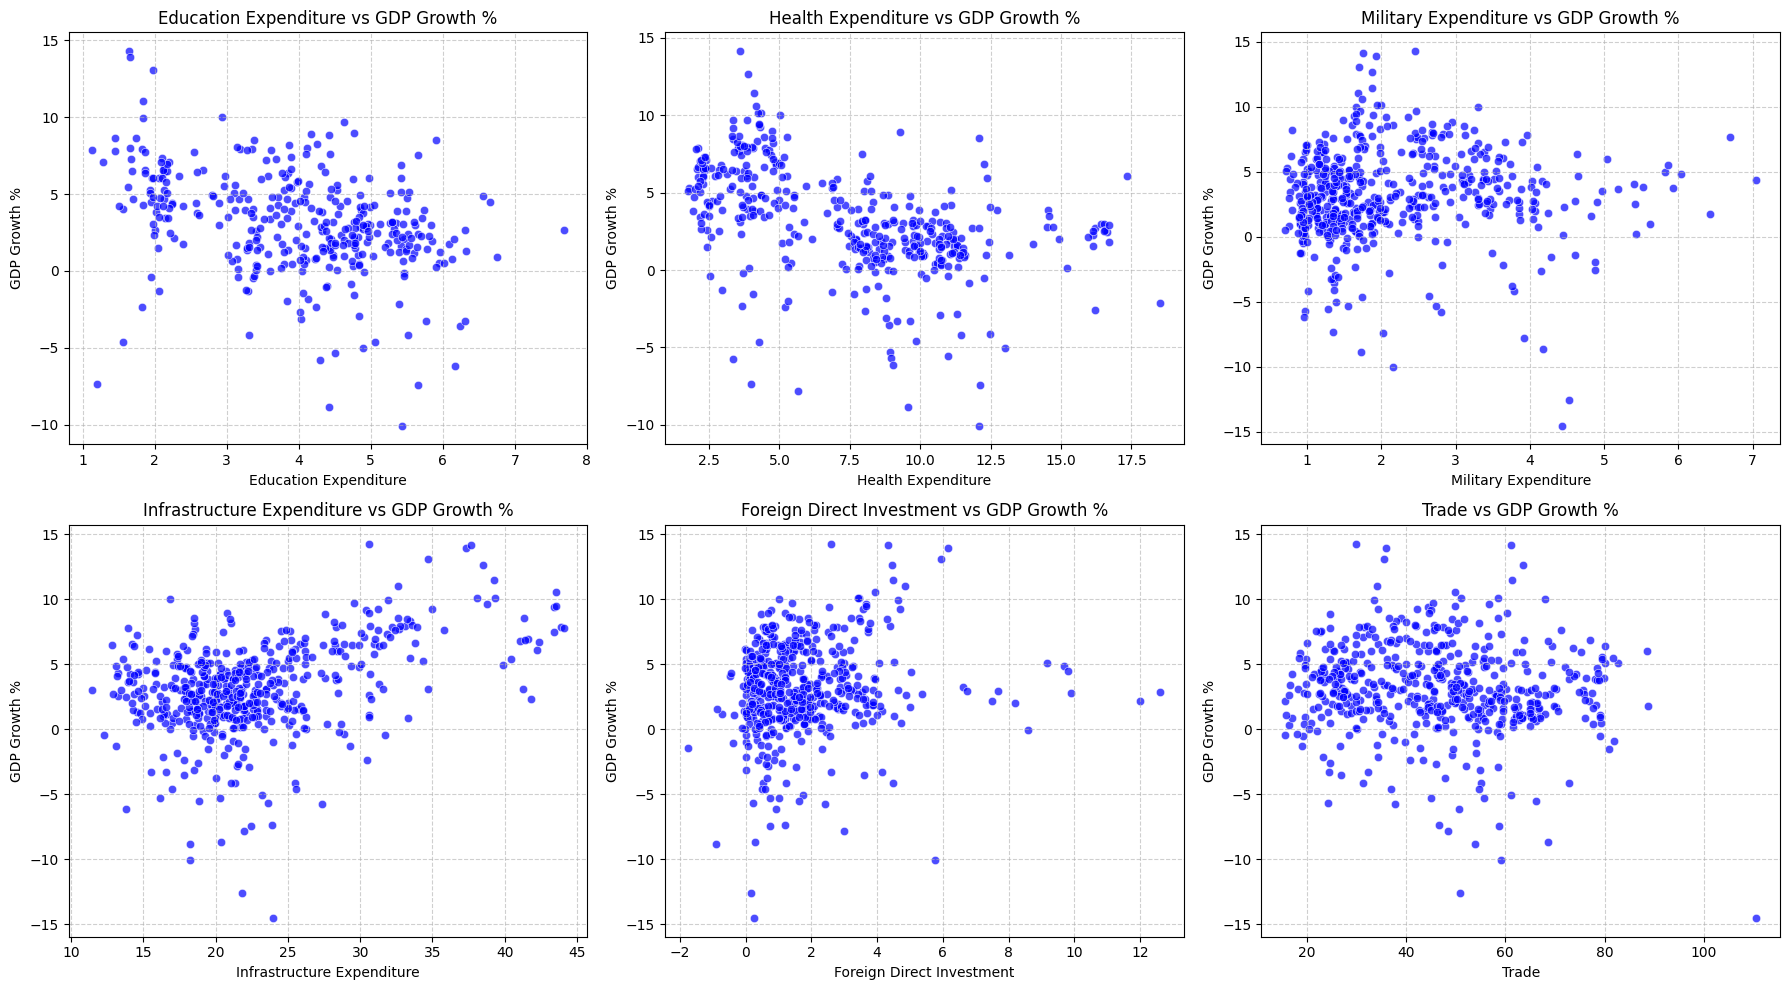

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.scatterplot(
        data=df,
        x=feature,
        y='GDP Growth %',
        ax=axes[i],
        alpha=0.7,
        color='blue'
    )
    axes[i].set_title(f'{feature} vs GDP Growth %')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('GDP Growth %')
    axes[i].grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()

plt.savefig('2d_scatterplots.png', bbox_inches='tight')
plt.show()

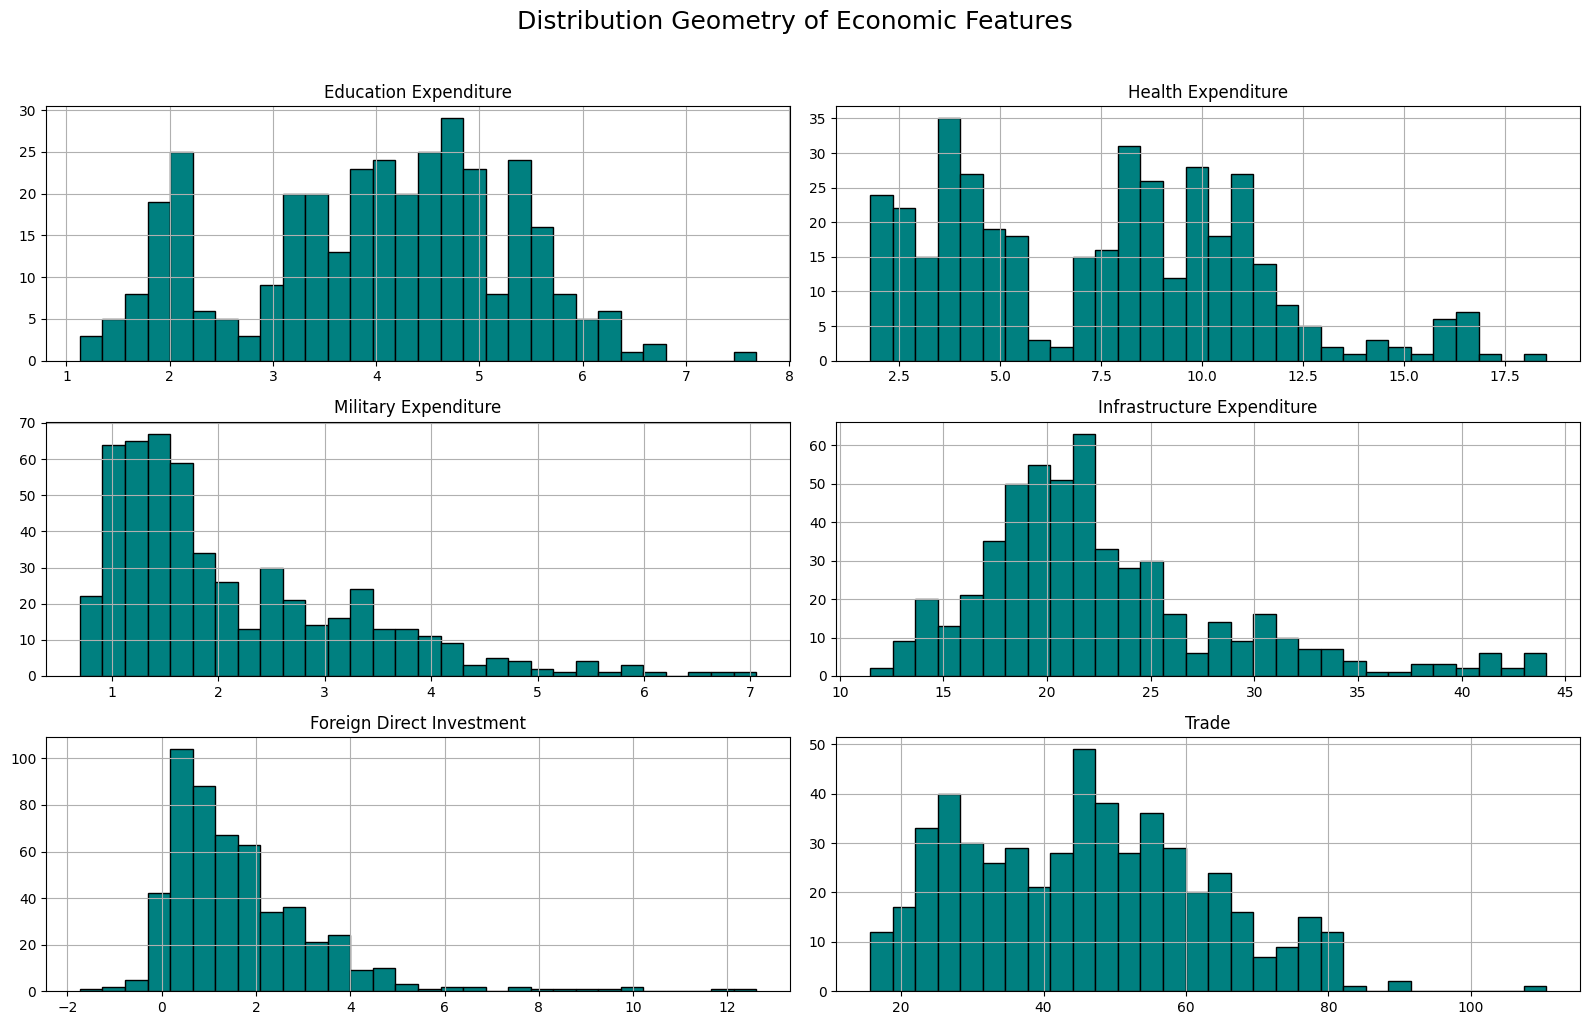

In [33]:
features_to_plot = df[numerical_features]

features_to_plot.hist(bins=30, figsize=(16, 10), color='teal', edgecolor='black')

plt.suptitle("Distribution Geometry of Economic Features", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Splitting the training and testing data

In [34]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

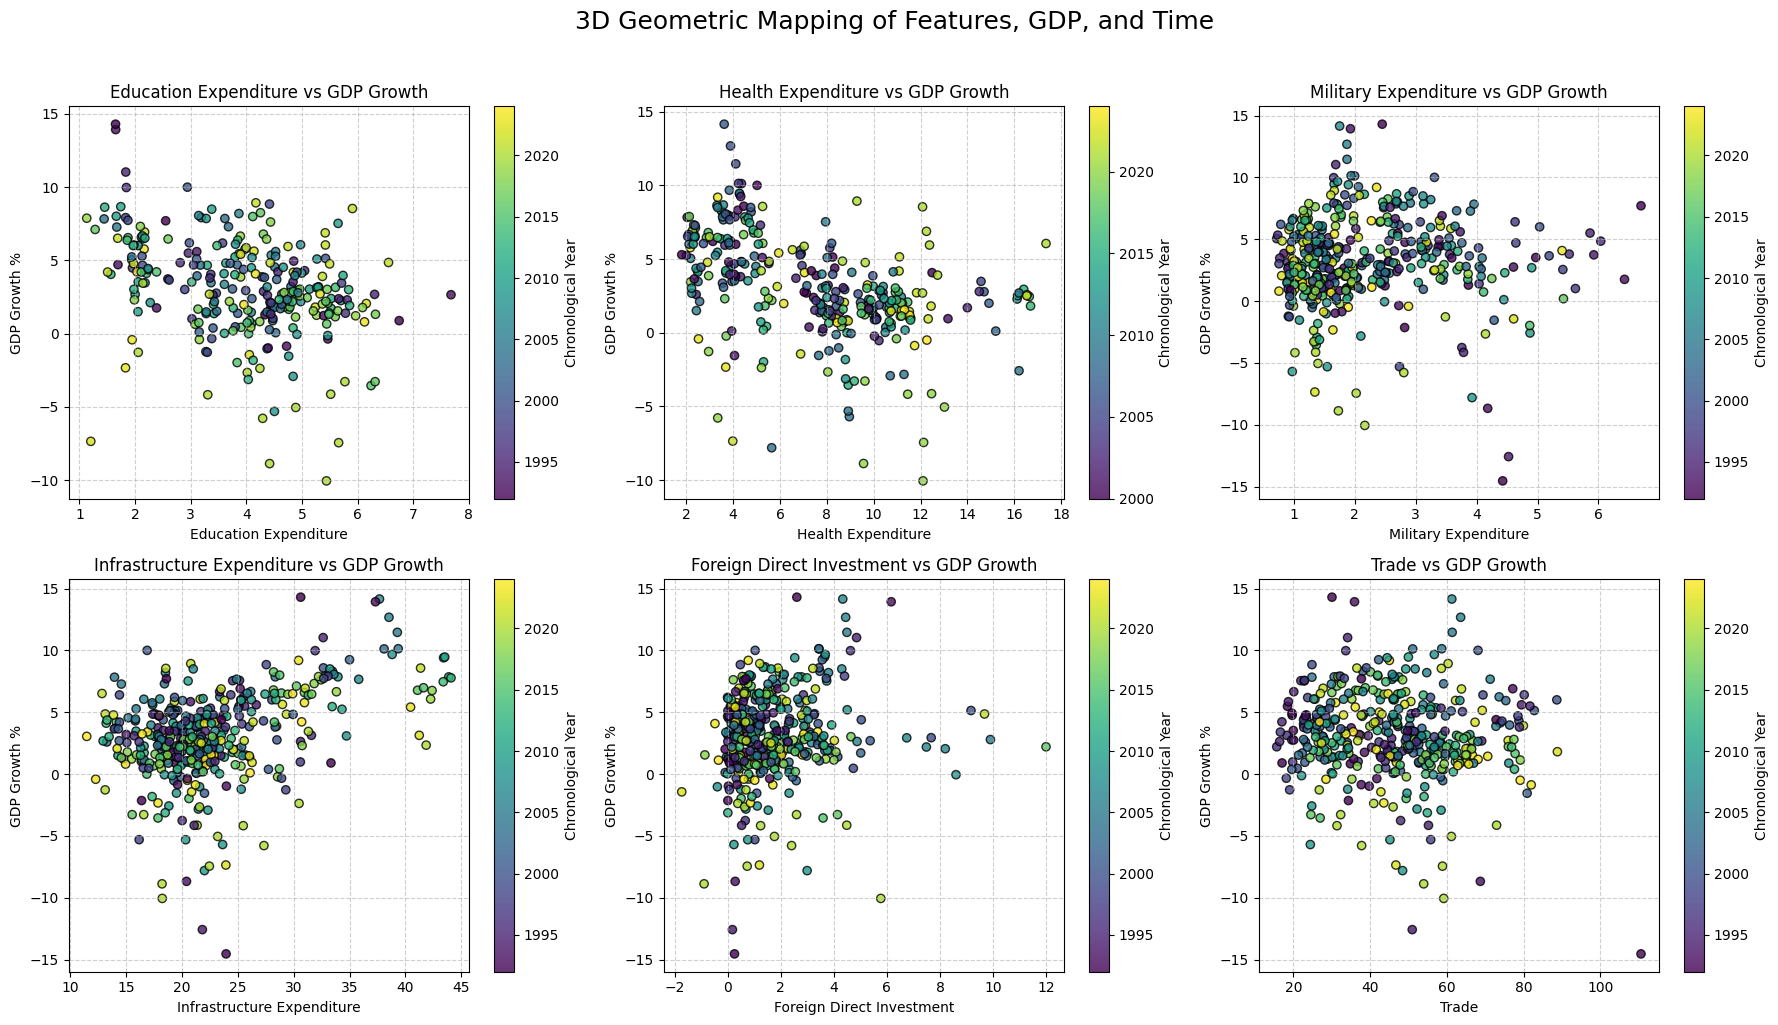

In [35]:
explore_df = X_train.copy()
explore_df['GDP Growth %'] = y_train

explore_df['year'] = df.loc[X_train.index, 'year']

features_to_plot = [
    'Education Expenditure',
    'Health Expenditure',
    'Military Expenditure',
    'Infrastructure Expenditure',
    'Foreign Direct Investment',
    'Trade'
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)

    scatter = plt.scatter(explore_df[col], explore_df['GDP Growth %'],
                          c=explore_df['year'], cmap='viridis', alpha=0.8, edgecolor='k')

    plt.title(f"{col} vs GDP Growth")
    plt.xlabel(col)
    plt.ylabel("GDP Growth %")
    plt.grid(True, linestyle='--', alpha=0.6)

    cbar = plt.colorbar(scatter)
    cbar.set_label('Chronological Year')

plt.suptitle("3D Geometric Mapping of Features, GDP, and Time", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

##Dependency Matrix

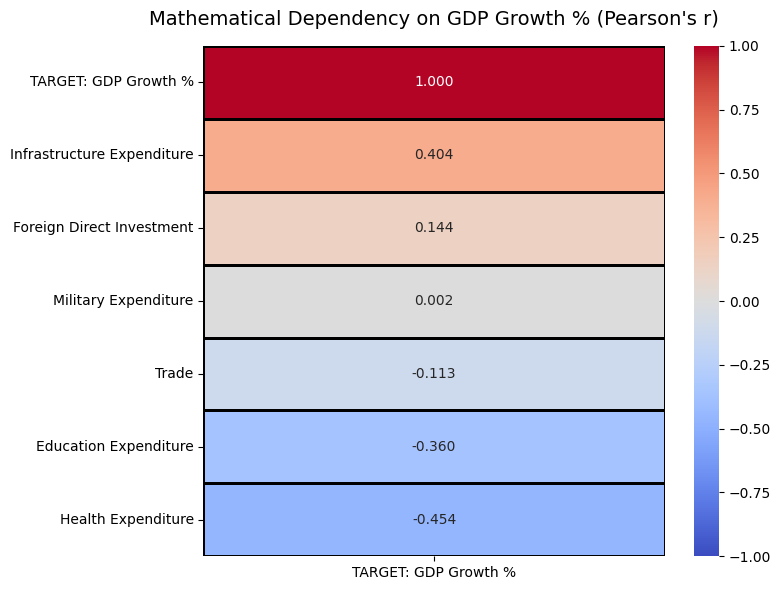

<Figure size 640x480 with 0 Axes>

In [36]:
dependency_matrix = X_train[numerical_features].copy()
dependency_matrix['TARGET: GDP Growth %'] = y_train

corr_matrix = dependency_matrix.corr()

target_dependency = corr_matrix[['TARGET: GDP Growth %']].sort_values(by='TARGET: GDP Growth %', ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(target_dependency, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            linewidths=1, linecolor='black')

plt.title("Mathematical Dependency on GDP Growth % (Pearson's r)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

plt.savefig('dependency_matrix.png', bbox_inches='tight')

##Correlation Scatterplots

## The strongest macroeconomic driver(Infrastructure Expenditure)




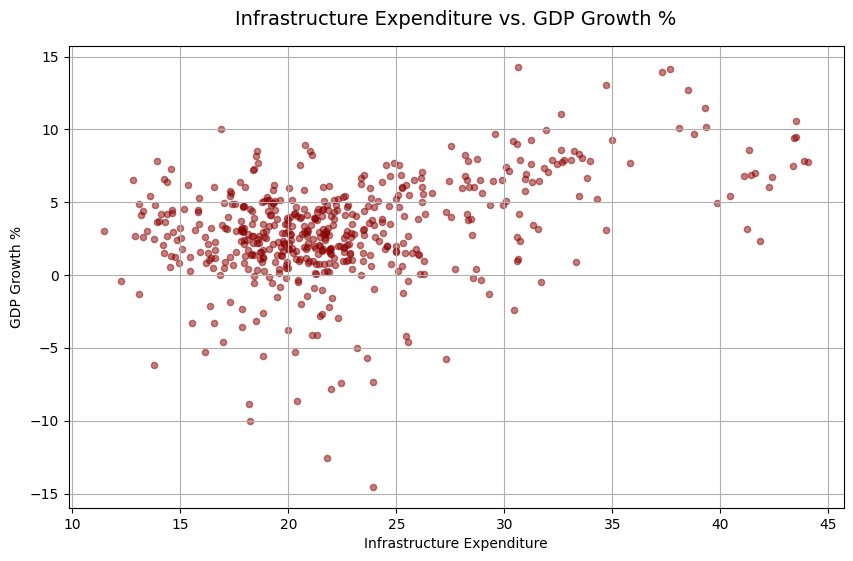

In [37]:
df.plot(
    kind="scatter",
    x="Infrastructure Expenditure",
    y="GDP Growth %",
    alpha=0.5,
    figsize=(10, 6),
    color="darkred",
    grid=True
)

plt.title("Infrastructure Expenditure vs. GDP Growth %", fontsize=14, pad=15)
plt.show()

#Step 05: Building a Transformation Pipeline

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),

    ('power_transform', PowerTransformer(method='yeo-johnson', standardize=False)),

    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', cat_pipeline, categorical_features)
    ]
)

##Just after Imputation and PowerTransform

##Expansion by One Hot Encoder

In [39]:
preprocessor.fit(X_train)
new_dimensions = preprocessor.get_feature_names_out()

print(f"Original number of columns: {X_train.shape[1]}")
print(f"New number of dimensions (columns): {len(new_dimensions)}\n")

print("The newly created vector space:")
print(new_dimensions)

Original number of columns: 7
New number of dimensions (columns): 22

The newly created vector space:
['num__Education Expenditure' 'num__Health Expenditure'
 'num__Military Expenditure' 'num__Infrastructure Expenditure'
 'num__Foreign Direct Investment' 'num__Trade' 'cat__country_Bangladesh'
 'cat__country_Brazil' 'cat__country_Canada' 'cat__country_China'
 'cat__country_France' 'cat__country_Germany' 'cat__country_India'
 'cat__country_Italy' 'cat__country_Japan' 'cat__country_Nepal'
 'cat__country_Pakistan' 'cat__country_Russian Federation'
 'cat__country_South Africa' 'cat__country_Sri Lanka'
 'cat__country_United Kingdom' 'cat__country_United States']


In [40]:
X_train_processed = preprocessor.fit_transform(X_train)

processed_df = pd.DataFrame(
    X_train_processed,
    columns=new_dimensions,
    index=X_train.index
)


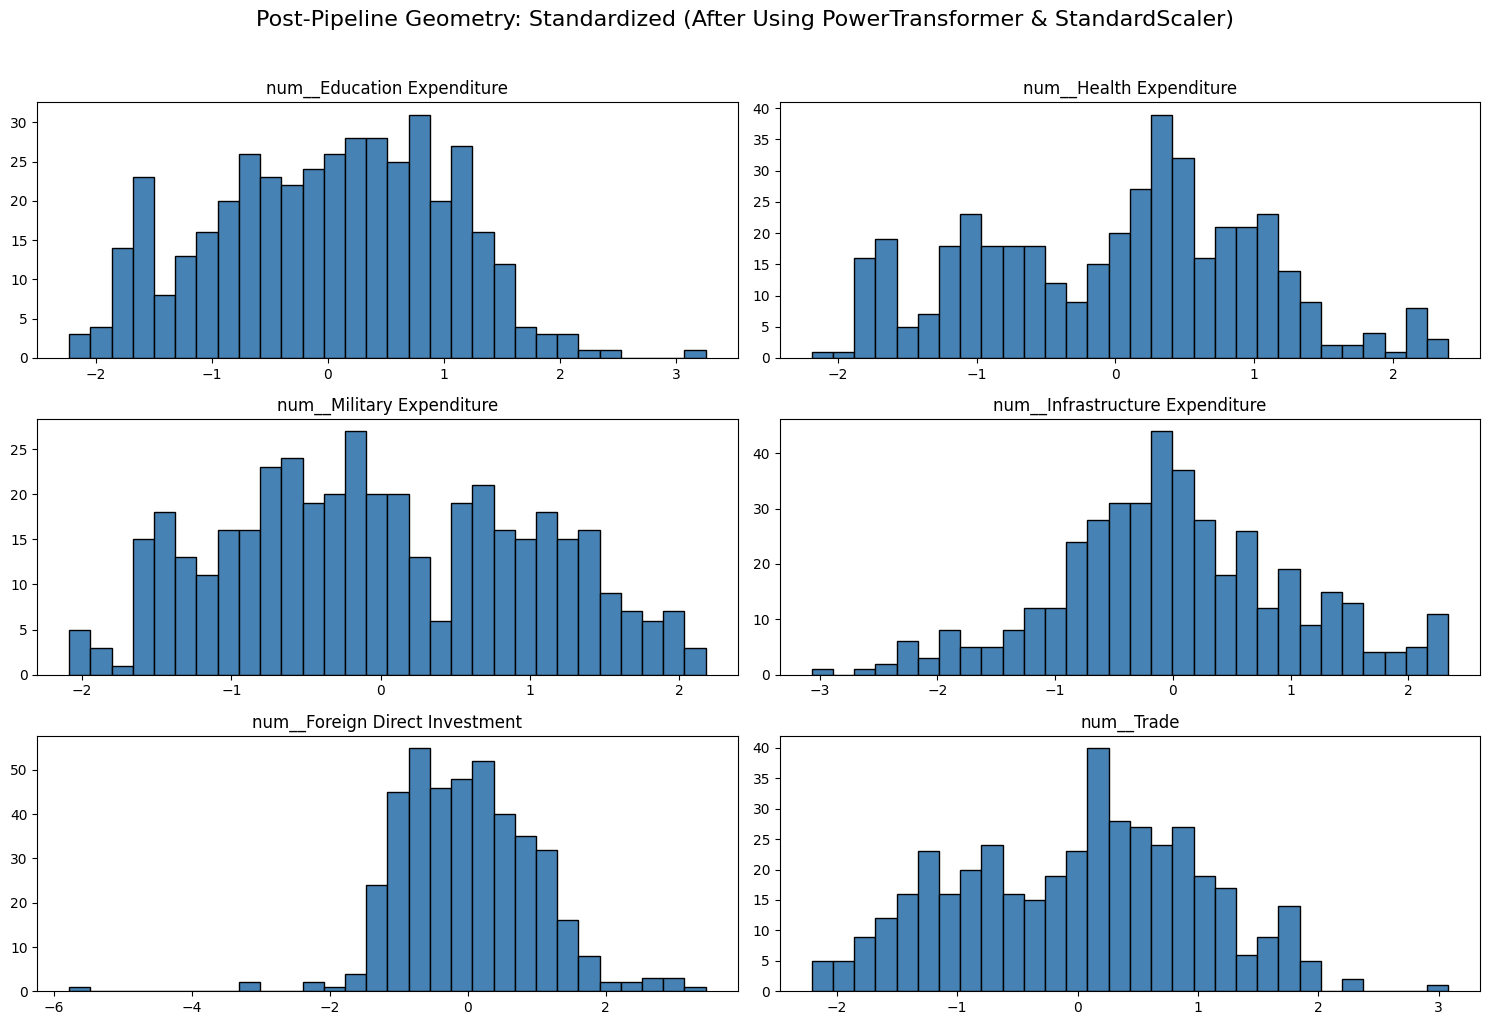

In [41]:

numeric_cols = [col for col in processed_df.columns if col.startswith('num_')]

processed_df[numeric_cols].hist(
    bins=30,
    figsize=(15, 10),
    color='steelblue',
    edgecolor='black',
    grid=False
)

plt.suptitle("Post-Pipeline Geometry: Standardized (After Using PowerTransformer & StandardScaler)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
processed_df


,num__Education Expenditure,num__Health Expenditure,num__Military Expenditure,num__Infrastructure Expenditure,num__Foreign Direct Investment,num__Trade,cat__country_Bangladesh,cat__country_Brazil,cat__country_Canada,cat__country_China,...,cat__country_India,cat__country_Italy,cat__country_Japan,cat__country_Nepal,cat__country_Pakistan,cat__country_Russian Federation,cat__country_South Africa,cat__country_Sri Lanka,cat__country_United Kingdom,cat__country_United States
524,1.195107,2.396163,1.176463,-0.004150,0.442443,-1.290311,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
155,1.130094,1.177847,0.010624,-0.208603,0.265337,1.068401,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
369,0.447073,0.455981,0.775986,-1.279167,-0.285088,0.667393,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
69,1.985231,1.372293,-0.387855,-0.695561,0.561334,1.340530,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
367,-0.129601,0.085537,1.344037,-0.323449,-0.614394,0.228327,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.827255,0.574817,-0.875763,-0.261430,0.597436,1.588090,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,-1.700118,-1.732835,0.012587,1.473515,1.269169,-0.712785,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,-0.597869,-0.178864,-1.541308,1.115769,-1.321388,-1.870404,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
435,-0.795133,-0.723128,1.679312,0.574803,-0.116694,1.776623,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [43]:
processed_df.describe()

,num__Education Expenditure,num__Health Expenditure,num__Military Expenditure,num__Infrastructure Expenditure,num__Foreign Direct Investment,num__Trade,cat__country_Bangladesh,cat__country_Brazil,cat__country_Canada,cat__country_China,...,cat__country_India,cat__country_Italy,cat__country_Japan,cat__country_Nepal,cat__country_Pakistan,cat__country_Russian Federation,cat__country_South Africa,cat__country_Sri Lanka,cat__country_United Kingdom,cat__country_United States
count,4.220000e+02,4.220000e+02,4.220000e+02,4.220000e+02,4.220000e+02,4.220000e+02,422.000000,422.000000,422.000000,422.000000,...,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000
mean,-4.419845e-17,-3.157032e-16,-8.797597e-16,-6.708694e-15,-1.683751e-17,-8.418753e-17,0.054502,0.066351,0.045024,0.066351,...,0.068720,0.066351,0.063981,0.059242,0.061611,0.068720,0.063981,0.068720,0.063981,0.056872
std,1.001187e+00,1.001187e+00,1.001187e+00,1.001187e+00,1.001187e+00,1.001187e+00,0.227276,0.249190,0.207602,0.249190,...,0.253278,0.249190,0.245010,0.236357,0.240734,0.253278,0.245010,0.253278,0.245010,0.231873
min,-2.228325e+00,-2.187248e+00,-2.086120e+00,-3.067152e+00,-5.783817e+00,-2.207277e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.417866e-01,-8.212652e-01,-7.408700e-01,-6.099095e-01,-6.873981e-01,-7.980685e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.411420e-02,1.697064e-01,-9.198149e-02,-2.846186e-02,-7.804658e-02,1.143752e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.850874e-01,7.260886e-01,8.099114e-01,6.034866e-01,6.309375e-01,7.175989e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.254528e+00,2.396163e+00,2.175621e+00,2.338532e+00,3.450927e+00,3.077842e+00,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#**Step 06**: Modeling

##Linear Regression

In [44]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('power_transform',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Education Expenditure',
                                                   'Health Expenditure',
                                                   'Military Expenditure',
                                                   'Infrastructure Expenditure',
                                                   'Foreign Direct Investment',
                                                   'Trade']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country'])])),
                ('regressor', LinearRegression())])

In [45]:
trained_regressor = lr_model.named_steps['regressor']

bias = trained_regressor.intercept_

weights = trained_regressor.coef_

print(f"Intercept: {bias}")
print(f"Weights: {weights}")

Intercept: 3.1511656425756964
Weights: [-0.27761819 -0.91179909  0.4073487  -0.10330813  0.68276889  0.12816798
  1.83598234 -0.19644625 -0.0374421   4.09130608 -0.86079752 -0.94949769
  1.96598311 -1.69880285 -0.65758787  1.38207221 -1.39166876 -3.15583452
  0.1917756  -0.0137287  -1.07637743  0.57106434]


In [46]:
feature_names = lr_model.named_steps['preprocessor'].get_feature_names_out()

weights_df = pd.DataFrame({
    'Indicator': feature_names,
    'SVD_Weight': trained_regressor.coef_
})

print(f"Intercept: {bias}")
print(weights_df)

Intercept: 3.1511656425756964
                          Indicator  SVD_Weight
0        num__Education Expenditure   -0.277618
1           num__Health Expenditure   -0.911799
2         num__Military Expenditure    0.407349
3   num__Infrastructure Expenditure   -0.103308
4    num__Foreign Direct Investment    0.682769
5                        num__Trade    0.128168
6           cat__country_Bangladesh    1.835982
7               cat__country_Brazil   -0.196446
8               cat__country_Canada   -0.037442
9                cat__country_China    4.091306
10              cat__country_France   -0.860798
11             cat__country_Germany   -0.949498
12               cat__country_India    1.965983
13               cat__country_Italy   -1.698803
14               cat__country_Japan   -0.657588
15               cat__country_Nepal    1.382072
16            cat__country_Pakistan   -1.391669
17  cat__country_Russian Federation   -3.155835
18        cat__country_South Africa    0.191776
19        

##KNN

In [47]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('power_transform',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Education Expenditure',
                                                   'Health Expenditure',
                                                   'Military Expenditure',
                                                   'Infrastructure Expenditure',
                                                   'Foreign Direct Investment',
                                                   'Trade']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country'])])),
                ('regressor', KNeighborsRegressor())])

## Decision Tree

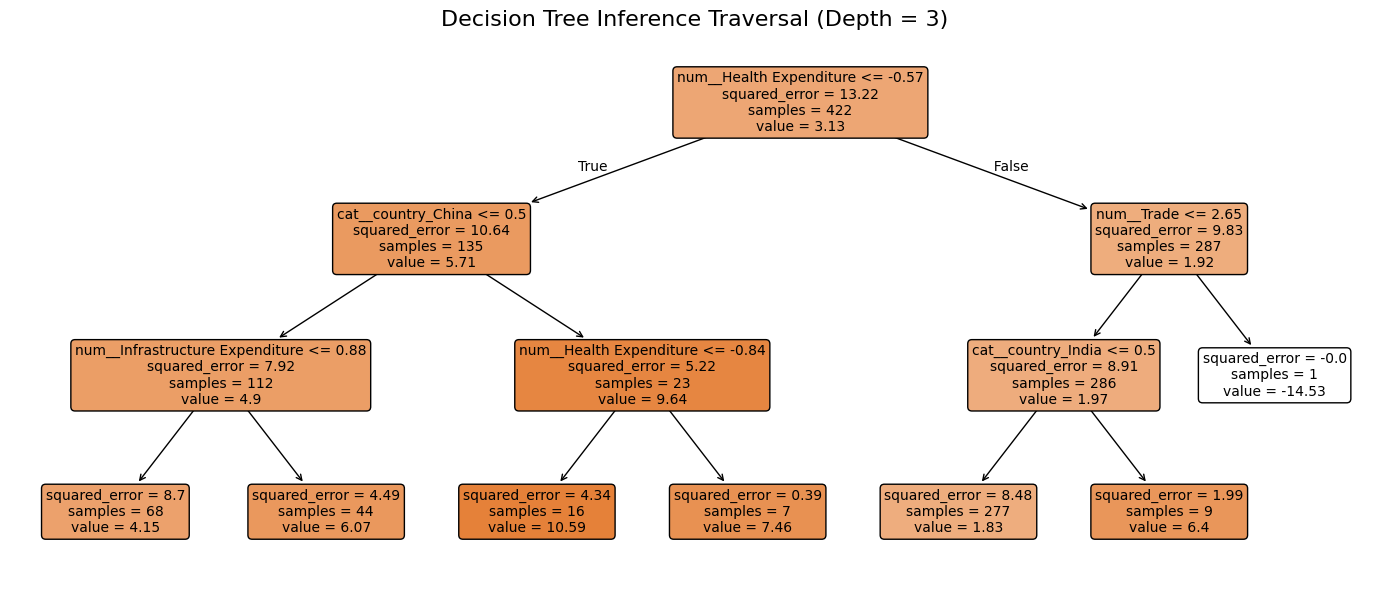

In [48]:
from sklearn.tree import DecisionTreeRegressor, plot_tree


dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        max_depth=3,
        random_state=42,
    ))
])


dt_model.fit(X_train, y_train)


trained_tree = dt_model.named_steps['regressor']

feature_names = dt_model.named_steps['preprocessor'].get_feature_names_out()


plt.figure(figsize=(14, 6))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2
)
plt.title("Decision Tree Inference Traversal (Depth = 3)", fontsize=16)
plt.tight_layout()

plt.savefig('decision_tree_depth_3.jpg', dpi=300, bbox_inches='tight')
plt.show()


##Random Forest


In [49]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=1000,
        max_depth=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('power_transform',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Education Expenditure',
                                                   'Health Expenditure',
                                                   'Military Expenditure',
                                                   'Infrastructure Expenditure',
                                                   'Foreign Direct Investment',
                                                   'Trade']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=4, max_features='sqrt',
                                       n_estimators=1000, n_jobs=-1,
                                       random_state=42))])

##XGBoost

In [50]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        colsample_bytree=0.8,
        subsample=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('power_transform',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Education Expenditure',
                                                   'Health Expenditure',
                                                   'Military Expenditure',
                                                   'Infrastructure Expenditure',
                                                   'Foreign Direct Investment',
                                                   'Trade']),
                                                 (...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

#**Step 07**: Evaluation

##Linear Regression

In [51]:
cv_scores_lr = -cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
cv_rmse_mean_lr = cv_scores_lr.mean()
cv_rmse_std_lr = cv_scores_lr.std()


y_pred = lr_model.predict(X_test)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2_lr = r2_score(y_test, y_pred)


print(f"--- Linear Regression Results ---")
print(f"CV RMSE (5-Fold): {cv_rmse_mean_lr:.2f} (± {cv_rmse_std_lr:.2f})")
print(f"Test RMSE:        {test_rmse_lr:.2f}")
print(f"Test R2 Score:    {test_r2_lr:.4f}")

if test_rmse_lr<cv_rmse_mean_lr:
  print(f"good")

--- Linear Regression Results ---
CV RMSE (5-Fold): 2.97 (± 0.40)
Test RMSE:        2.21
Test R2 Score:    0.4884
good


##KNN

In [52]:
cv_scores_knn = -cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse_mean_knn = cv_scores_knn.mean()
cv_rmse_std_knn = cv_scores_knn.std()

y_pred_knn = knn_model.predict(X_test)
test_rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
test_r2_knn = r2_score(y_test, y_pred_knn)

print(f"--- KNN Results ---")
print(f"CV RMSE (5-Fold): {cv_rmse_mean_knn:.2f} (± {cv_rmse_std_knn:.2f})")
print(f"Test RMSE:        {test_rmse_knn:.2f}")
print(f"Test R2 Score:    {test_r2_knn:.4f}")

--- KNN Results ---
CV RMSE (5-Fold): 2.91 (± 0.40)
Test RMSE:        2.42
Test R2 Score:    0.3840


## Decision Tree

In [53]:
cv_scores_dt = -cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
cv_rmse_mean_dt = cv_scores_dt.mean()
cv_rmse_std_dt = cv_scores_dt.std()

y_pred_dt = dt_model.predict(X_test)
test_rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
test_r2_dt = r2_score(y_test, y_pred_dt)

print(f"--- Decision Tree Results ---")
print(f"CV RMSE (5-Fold): {cv_rmse_mean_dt:.2f} (± {cv_rmse_std_dt:.2f})")
print(f"Test RMSE:        {test_rmse_dt:.2f}")
print(f"Test R2 Score:    {test_r2_dt:.4f}")

if test_rmse_dt < cv_rmse_mean_dt:
    print("good")

--- Decision Tree Results ---
CV RMSE (5-Fold): 3.38 (± 0.41)
Test RMSE:        2.42
Test R2 Score:    0.3862
good


##Random Forest

In [54]:
cv_scores_rf = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
cv_rmse_mean_rf = cv_scores_rf.mean()
cv_rmse_std_rf = cv_scores_rf.std()

y_pred_rf = rf_model.predict(X_test)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
test_r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest (RF) Results ---")
print(f"CV RMSE (5-Fold): {cv_rmse_mean_rf:.2f} (± {cv_rmse_std_rf:.2f})")
print(f"Test RMSE:        {test_rmse_rf:.2f}")
print(f"Test R2 Score:    {test_r2_rf:.4f}")

--- Random Forest (RF) Results ---
CV RMSE (5-Fold): 2.89 (± 0.45)
Test RMSE:        2.33
Test R2 Score:    0.4307


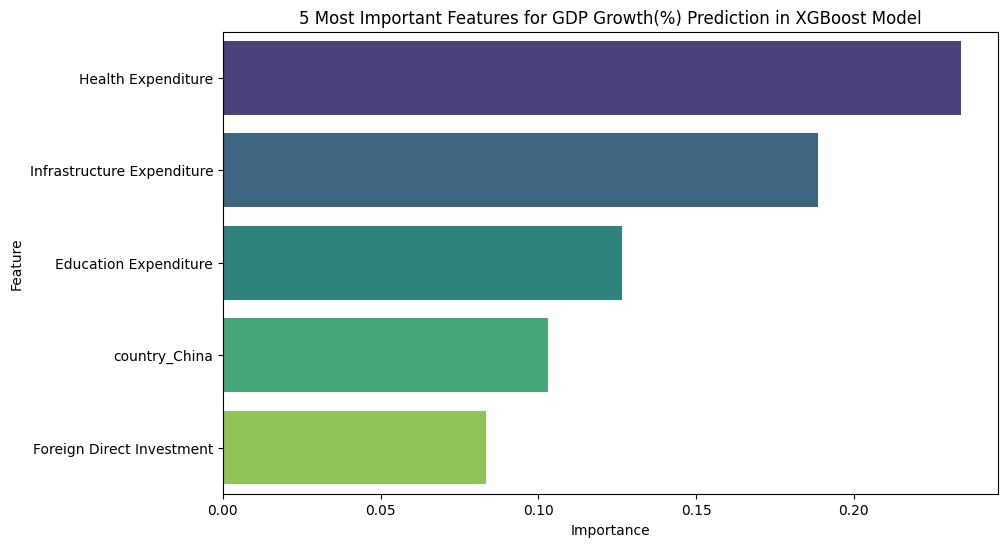

In [55]:
preprocessor_step = rf_model.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]

importances = rf_model.named_steps['regressor'].feature_importances_

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('5 Most Important Features for GDP Growth(%) Prediction in XGBoost Model')
plt.show()

##XGBoost

In [56]:
cv_scores_xgb = -cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
cv_rmse_mean_xgb = cv_scores_xgb.mean()
cv_rmse_std_xgb = cv_scores_xgb.std()

y_pred_xgb = xgb_model.predict(X_test)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
test_r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"--- XGBoost Results ---")
print(f"CV RMSE (5-Fold): {cv_rmse_mean_xgb:.2f} (± {cv_rmse_std_xgb:.2f})")
print(f"Test RMSE:        {test_rmse_xgb:.2f}")
print(f"Test R2 Score:    {test_r2_xgb:.4f}")

--- XGBoost Results ---
CV RMSE (5-Fold): 2.87 (± 0.42)
Test RMSE:        2.13
Test R2 Score:    0.5264


In [57]:
test_results_df = pd.DataFrame({
    'Country': df.loc[X_test.index, 'country'],
    'Year': df.loc[X_test.index, 'year'],
    'Actual_Growth': y_test
})

test_results_df['Predicted_Growth'] = xgb_model.predict(X_test)

test_results_df['Error'] = abs(test_results_df['Actual_Growth'] - test_results_df['Predicted_Growth'])

test_results_df = test_results_df.sort_values(by='Error', ascending=False)

print("--- Not Tuned XGB MODEL Worst 15 PREDICTION RESULTS) ---")
print(test_results_df.head(15))

--- Not Tuned XGB MODEL Worst 15 PREDICTION RESULTS) ---
                Country  Year  Actual_Growth  Predicted_Growth     Error
457           Sri Lanka  2020      -4.624515          3.903159  8.527674
424        South Africa  2020      -6.168918          1.183635  7.352553
182             Germany  2009      -5.544555          1.344193  6.888747
479      United Kingdom  2009      -4.587408          1.833105  6.420514
299               Nepal  1994       8.216003          3.215015  5.000987
523       United States  2020      -2.163029          2.066663  4.229692
68               Canada  1994       4.494049          0.669128  3.824921
33               Brazil  1992      -0.544072          3.113232  3.657304
227               India  2021       9.689592          6.247830  3.441762
104               China  1997       9.287647          5.925606  3.362041
322               Nepal  2017       8.977279          5.654153  3.323126
395  Russian Federation  2024       4.344375          1.053739  3.2

In [58]:
print("--- Primary MODEL - RANDOM 20 PREDICTIONS ---")
print(test_results_df.sample(n=20))

--- Primary MODEL - RANDOM 20 PREDICTIONS ---
                Country  Year  Actual_Growth  Predicted_Growth     Error
468      United Kingdom  1998       3.246315          3.326966  0.080651
322               Nepal  2017       8.977279          5.654153  3.323126
299               Nepal  1994       8.216003          3.215015  5.000987
93               Canada  2019       1.908432          2.346493  0.438061
137              France  1997       2.527062          2.624148  0.097087
30           Bangladesh  2022       7.099829          6.300681  0.799148
72               Canada  1998       3.892887          2.254793  1.638094
220               India  2014       7.410228          5.867321  1.542907
355            Pakistan  2017       4.432626          4.283343  0.149283
395  Russian Federation  2024       4.344375          1.053739  3.290635
497       United States  1994       4.029023          2.846523  1.182499
82               Canada  2008       0.995406          2.283258  1.287852
457  


FINAL ML MODEL LEADERBOARD



,Algorithm,CV RMSE Mean(5-Fold),Test RMSE,CV RMSE Std(5-Fold),Test R² Score
0,Extreme Gradient Boosting (XGBoost),2.867028,2.126058,0.421540,0.526369
1,Linear Regression,2.967149,2.209533,0.401695,0.488447
2,Random Forest,2.893832,2.331006,0.448868,0.430653
3,K-Nearest Neighbors,2.913843,2.424538,0.400137,0.384046


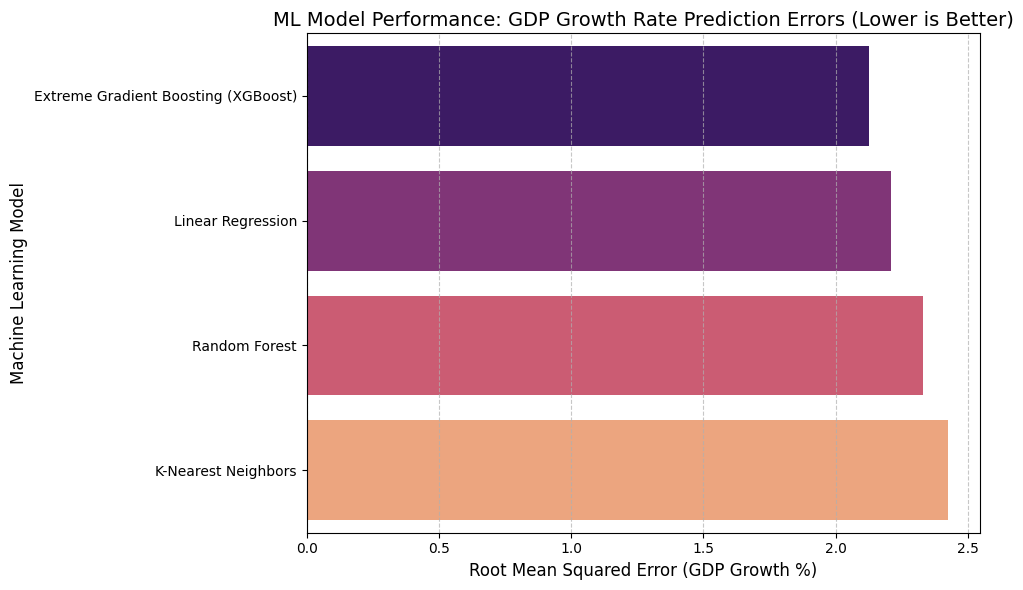

In [59]:

model_results = {
    "Algorithm": [
        "Linear Regression",
        "Random Forest",
        "Extreme Gradient Boosting (XGBoost)",
        "K-Nearest Neighbors"
    ],
    "CV RMSE Mean(5-Fold)": [
        cv_rmse_mean_lr,
        cv_rmse_mean_rf,
        cv_rmse_mean_xgb,
        cv_rmse_mean_knn
    ],
    "Test RMSE": [
        test_rmse_lr,
        test_rmse_rf,
        test_rmse_xgb,
        test_rmse_knn
    ],

    "CV RMSE Std(5-Fold)": [
        cv_rmse_std_lr,
        cv_rmse_std_rf,
        cv_rmse_std_xgb,
        cv_rmse_std_knn
    ],

    "Test R² Score": [
        test_r2_lr,
        test_r2_rf,
        test_r2_xgb,
        test_r2_knn
    ]
}

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="Test RMSE", ascending=True).reset_index(drop=True)

print("\nFINAL ML MODEL LEADERBOARD\n")
display(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Test RMSE",
    y="Algorithm",
    data=results_df,
    palette="magma"
)
plt.title("ML Model Performance: GDP Growth Rate Prediction Errors (Lower is Better)", fontsize=14)
plt.xlabel("Root Mean Squared Error (GDP Growth %)", fontsize=12)
plt.ylabel("Machine Learning Model", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Phase 2: Hyperparameter Optimization of the Champion Model(XgBoost)

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],

    'regressor__max_depth': [3, 4, 5],

    'regressor__learning_rate': [0.01, 0.05, 0.1],

    'regressor__reg_lambda': [1, 5, 10]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

print("Executing XGBoost Grid Search...")
grid_search_xgb.fit(X_train, y_train)

champion_xgb = grid_search_xgb.best_estimator_

print("\n--- XGBoost Grid Search Complete ---")
print("Optimal Hyperparameters:")
print(grid_search_xgb.best_params_)

Executing XGBoost Grid Search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

--- XGBoost Grid Search Complete ---
Optimal Hyperparameters:
{'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__n_estimators': 100, 'regressor__reg_lambda': 5}


In [61]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

champion_xgb = grid_search_xgb.best_estimator_

tuned_cv_rmse_mean = -grid_search_xgb.best_score_

best_index = grid_search_xgb.best_index_
tuned_cv_rmse_std = grid_search_xgb.cv_results_['std_test_score'][best_index]

y_pred_tuned = champion_xgb.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("==================================================")
print(" XGBoost: BEFORE vs. AFTER OPTIMIZATION ")
print("==================================================")

print("--- BASELINE (Default Parameters) ---")
print(f"Test RMSE: {test_rmse_xgb:.4f}")
print(f"Test R²:   {test_r2_xgb:.4f}\n")

print("--- TUNED (5-Fold Grid Search) ---")
print(f"CV RMSE (5-Fold): {tuned_cv_rmse_mean:.4f} (± {tuned_cv_rmse_std:.4f})")
print(f"Test RMSE:        {tuned_rmse:.4f}")
print(f"Test R²:          {tuned_r2:.4f}\n")

improvement_r2 = tuned_r2 - test_r2_xgb
improvement_rmse = test_rmse_xgb - tuned_rmse

print("--- NET IMPROVEMENT ---")
print(f" Error Reduced By: {improvement_rmse:.4f}")
print(f" R² Increased By:  +{improvement_r2:.4f}")

if tuned_rmse < tuned_cv_rmse_mean:
    print("\nModel shows excellent generalization (Test RMSE < CV RMSE).")

print("==================================================")

 XGBoost: BEFORE vs. AFTER OPTIMIZATION 
--- BASELINE (Default Parameters) ---
Test RMSE: 2.1261
Test R²:   0.5264

--- TUNED (5-Fold Grid Search) ---
CV RMSE (5-Fold): 2.7901 (± 0.4515)
Test RMSE:        2.1138
Test R²:          0.5318

--- NET IMPROVEMENT ---
 Error Reduced By: 0.0123
 R² Increased By:  +0.0055

Model shows excellent generalization (Test RMSE < CV RMSE).


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_results = {
    "Algorithm": [
        "Linear Regression",
        "Random Forest",
        "XGBoost (Baseline)",
        "K-Nearest Neighbors",
        "XGBoost (Tuned)"
    ],
    "CV RMSE Mean(5-Fold)": [
        cv_rmse_mean_lr,
        cv_rmse_mean_rf,
        cv_rmse_mean_xgb,
        cv_rmse_mean_knn,
        tuned_cv_rmse_mean
    ],
    "Test RMSE": [
        test_rmse_lr,
        test_rmse_rf,
        test_rmse_xgb,
        test_rmse_knn,
        tuned_rmse
    ],
    "CV RMSE Std(5-Fold)": [
        cv_rmse_std_lr,
        cv_rmse_std_rf,
        cv_rmse_std_xgb,
        cv_rmse_std_knn,
        tuned_cv_rmse_std
    ],
    "Test R² Score": [
        test_r2_lr,
        test_r2_rf,
        test_r2_xgb,
        test_r2_knn,
        tuned_r2
    ]
}

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="Test RMSE", ascending=True).reset_index(drop=True)

print("\nFINAL ML MODEL LEADERBOARD\n")
display(results_df)



FINAL ML MODEL LEADERBOARD



,Algorithm,CV RMSE Mean(5-Fold),Test RMSE,CV RMSE Std(5-Fold),Test R² Score
0,XGBoost (Tuned),2.790145,2.113769,0.451481,0.531829
1,XGBoost (Baseline),2.867028,2.126058,0.421540,0.526369
2,Linear Regression,2.967149,2.209533,0.401695,0.488447
3,Random Forest,2.893832,2.331006,0.448868,0.430653
4,K-Nearest Neighbors,2.913843,2.424538,0.400137,0.384046


##Final Test (With best mdoel - tuned xgb - Using Our Own Test Data) - X_test is actually shuffled


In [63]:
test_results_df_final = pd.DataFrame({
    'Country': df.loc[X_test.index, 'country'],
    'Year': df.loc[X_test.index, 'year'],
    'Actual_Growth': y_test
})

test_results_df_final['Predicted_Growth'] = champion_xgb.predict(X_test)

test_results_df_final['Error'] = abs(test_results_df_final['Actual_Growth'] - test_results_df_final['Predicted_Growth'])

test_results_df_final = test_results_df_final.sort_values(by='Error', ascending=False)

print("--- TUNED MODEL (CHAMPION) PREDICTION RESULTS ---")
print(test_results_df_final.head(15))

--- TUNED MODEL (CHAMPION) PREDICTION RESULTS ---
            Country  Year  Actual_Growth  Predicted_Growth     Error
457       Sri Lanka  2020      -4.624515          3.744641  8.369156
424    South Africa  2020      -6.168918          1.518697  7.687615
182         Germany  2009      -5.544555          1.370989  6.915543
479  United Kingdom  2009      -4.587408          1.390769  5.978177
299           Nepal  1994       8.216003          3.158221  5.057782
33           Brazil  1992      -0.544072          3.525262  4.069334
523   United States  2020      -2.163029          1.886028  4.049057
322           Nepal  2017       8.977279          5.360066  3.617213
104           China  1997       9.287647          5.777992  3.509654
227           India  2021       9.689592          6.295065  3.394527
68           Canada  1994       4.494049          1.224515  3.269534
101           China  1994      13.072709          9.833009  3.239700
73           Canada  1999       5.141004          2.2

In [64]:
print("--- TUNED MODEL (CHAMPION) RANDOM 20 PREDICTIONS ---")
print(test_results_df_final.sample(n=20))

--- TUNED MODEL (CHAMPION) RANDOM 20 PREDICTIONS ---
                Country  Year  Actual_Growth  Predicted_Growth     Error
89               Canada  2015       0.649971          2.950710  2.300739
227               India  2021       9.689592          6.295065  3.394527
382  Russian Federation  2011       4.300029          4.469658  0.169629
329               Nepal  2024       3.665374          3.168065  0.497309
375  Russian Federation  2004       7.199948          6.392498  0.807450
468      United Kingdom  1998       3.246315          2.950523  0.295792
498       United States  1995       2.684431          3.632215  0.947784
423        South Africa  2019       0.259936          2.335978  2.076042
255               Italy  2016       1.236221          0.104899  1.131322
497       United States  1994       4.029023          2.508584  1.520438
355            Pakistan  2017       4.432626          4.256142  0.176484
131               China  2024       4.977357          6.968059  1.99070

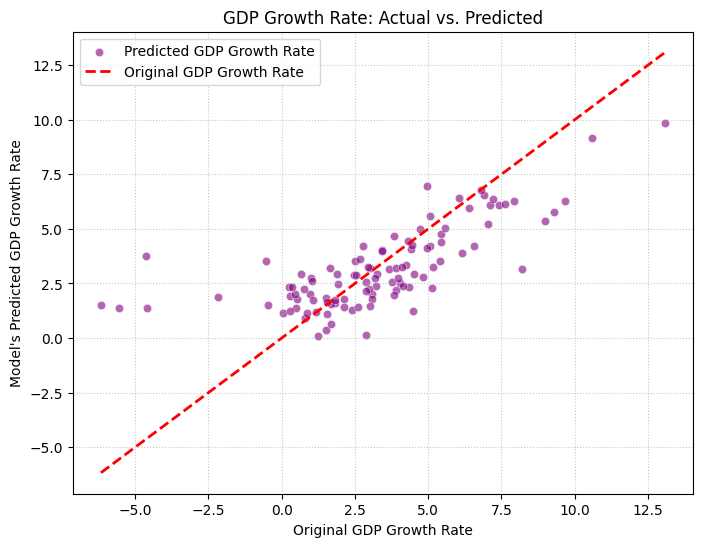

In [65]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred_tuned, color='purple', alpha=0.6, label='Predicted GDP Growth Rate')

line_coords = np.linspace(min(y_test.min(), y_pred_tuned.min()),
                          max(y_test.max(), y_pred_tuned.max()), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Original GDP Growth Rate')

plt.xlabel("Original GDP Growth Rate")
plt.ylabel("Model's Predicted GDP Growth Rate")
plt.title("GDP Growth Rate: Actual vs. Predicted")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [66]:
import pandas as pd

historical_df = X_test.copy()
historical_df['Actual_Growth'] = y_test
historical_df['Country'] = df.loc[X_test.index, 'country']
historical_df['Year'] = df.loc[X_test.index, 'year']

historical_df.to_csv('historical_test_data.csv', index=False)

print("historical_test_data.csv generated successfully")
print(f"Total historical coordinates exported: {len(historical_df)}")

historical_test_data.csv generated successfully
Total historical coordinates exported: 106


#Phase 3: Launching Model

In [67]:
import joblib

joblib.dump(champion_xgb, 'gdp_xgboost_model.pkl')

print("Model successfully saved as 'gdp_xgboost_model.pkl'")

Model successfully saved as 'gdp_xgboost_model.pkl'


In [68]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

X_inference = df[categorical_features + numerical_features]
y_pred_all = champion_xgb.predict(X_inference)

full_results = pd.DataFrame({
    'country': df['country'],
    'year': df['year'],
    'Actual': df['GDP Growth %'],
    'Predicted': y_pred_all
})

full_results['is_test'] = full_results.index.isin(X_test.index)

output_dir = 'forecast_plots'
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

for country in full_results['country'].unique():
    data = full_results[full_results['country'] == country].sort_values('year')
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(data['year'], data['Actual'], color='#2c3e50', linewidth=2, label='Observed (World Bank)', alpha=0.3)

    train_pts = data[~data['is_test']]
    ax.scatter(train_pts['year'], train_pts['Predicted'], color='#3498db', s=45, label='In-Sample Fit', alpha=0.6)

    test_pts = data[data['is_test']]
    ax.scatter(test_pts['year'], test_pts['Predicted'], color='#e74c3c', marker='s', s=80, label='Out-of-Sample Validation', zorder=5)

    ax.set_title(f"Observed vs. Predicted GDP Growth: {country}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual GDP Growth Rate (%)")

    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

    plt.legend(loc='best')
    plt.tight_layout()


    safe_country_name = country.replace(' ', '_')
    filepath = os.path.join(output_dir, f"{safe_country_name}_forecast.png")

    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved plot for {country} -> {filepath}")

    plt.close()

print(f"\nAll plots successfully exported to the '{output_dir}' folder")

Saved plot for Bangladesh -> forecast_plots/Bangladesh_forecast.png
Saved plot for Brazil -> forecast_plots/Brazil_forecast.png
Saved plot for Canada -> forecast_plots/Canada_forecast.png
Saved plot for China -> forecast_plots/China_forecast.png
Saved plot for France -> forecast_plots/France_forecast.png
Saved plot for Germany -> forecast_plots/Germany_forecast.png
Saved plot for India -> forecast_plots/India_forecast.png
Saved plot for Italy -> forecast_plots/Italy_forecast.png
Saved plot for Japan -> forecast_plots/Japan_forecast.png
Saved plot for Nepal -> forecast_plots/Nepal_forecast.png
Saved plot for Pakistan -> forecast_plots/Pakistan_forecast.png
Saved plot for Russian Federation -> forecast_plots/Russian_Federation_forecast.png
Saved plot for South Africa -> forecast_plots/South_Africa_forecast.png
Saved plot for Sri Lanka -> forecast_plots/Sri_Lanka_forecast.png
Saved plot for United Kingdom -> forecast_plots/United_Kingdom_forecast.png
Saved plot for United States -> foreca